# Project: Heart Attack Prediction
**Course**: Classification

In this notebook, the following steps will be performed: Data Loading → Data Understanding → Data Cleaning & Preprocessing → Exploratory Data Analysis (EDA) → Feature Preparation → Train/Test Split → Model Selection (KNN / Decision Tree / Logistic Regression / SVM) → Evaluation and Conclusion.

## Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

## Downloading Data

In [2]:
!wget -nv -O heart.csv "https://media1.maktabkhooneh.org/courses/projects/16325569497737558.csv?expire=1763908348&token=1e6af2a183261f434670e7e7ec1975f8&md5=HmryoYMmH0NGcOfn7Bl1-A==&_gl=1*6oe1q0*_gcl_au*MTI0OTk0MjU1My4xNzYyNjA4MDEyLjE0MzkyNjgxNzYuMTc2Mjg3MTM0Ni4xNzYyODcxMzc1"

2025-11-27 17:00:22 URL:https://media1.maktabkhooneh.org/courses/projects/16325569497737558.csv?expire=1763908348&token=1e6af2a183261f434670e7e7ec1975f8&md5=HmryoYMmH0NGcOfn7Bl1-A==&_gl=1*6oe1q0*_gcl_au*MTI0OTk0MjU1My4xNzYyNjA4MDEyLjE0MzkyNjgxNzYuMTc2Mjg3MTM0Ni4xNzYyODcxMzc1 [11323/11323] -> "heart.csv" [1]


## Reading Data

In [3]:
df = pd.read_csv("heart.csv")

## Data Overview

In [4]:
df.head(10)

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
7,44,1,1,120,263,0,1,173,0,0.0,2,0,3,1
8,52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
9,57,1,2,150,168,0,1,174,0,1.6,2,0,2,1


In [5]:
df.shape

(303, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trtbps    303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalachh  303 non-null    int64  
 8   exng      303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slp       303 non-null    int64  
 11  caa       303 non-null    int64  
 12  thall     303 non-null    int64  
 13  output    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [7]:
df.describe()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


# Clean the Data

## Changing Data Type of oldpeak Column

In [8]:
df['oldpeak'] = df['oldpeak'].astype('int')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   age       303 non-null    int64
 1   sex       303 non-null    int64
 2   cp        303 non-null    int64
 3   trtbps    303 non-null    int64
 4   chol      303 non-null    int64
 5   fbs       303 non-null    int64
 6   restecg   303 non-null    int64
 7   thalachh  303 non-null    int64
 8   exng      303 non-null    int64
 9   oldpeak   303 non-null    int64
 10  slp       303 non-null    int64
 11  caa       303 non-null    int64
 12  thall     303 non-null    int64
 13  output    303 non-null    int64
dtypes: int64(14)
memory usage: 33.3 KB


## Feature Set

In [10]:
df.columns

Index(['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 'thalachh',
       'exng', 'oldpeak', 'slp', 'caa', 'thall', 'output'],
      dtype='object')

## Visual Data Exploration (Histogram)

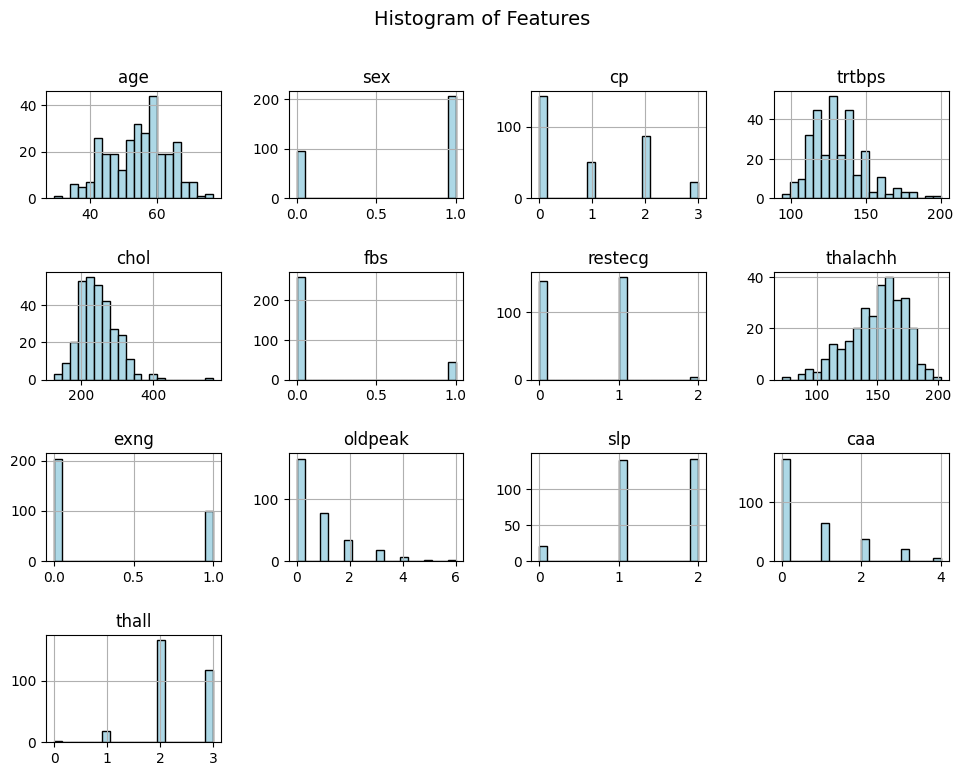

In [11]:
cols = ['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 'thalachh', 'exng', 'oldpeak', 'slp', 'caa', 'thall']
df[cols].hist(figsize=(10, 8), bins=20, color='lightblue', edgecolor='black')
plt.suptitle("Histogram of Features", fontsize=14)
plt.tight_layout(pad=2.0)
plt.show()

## Visual Data Exploration (Correlation Map)

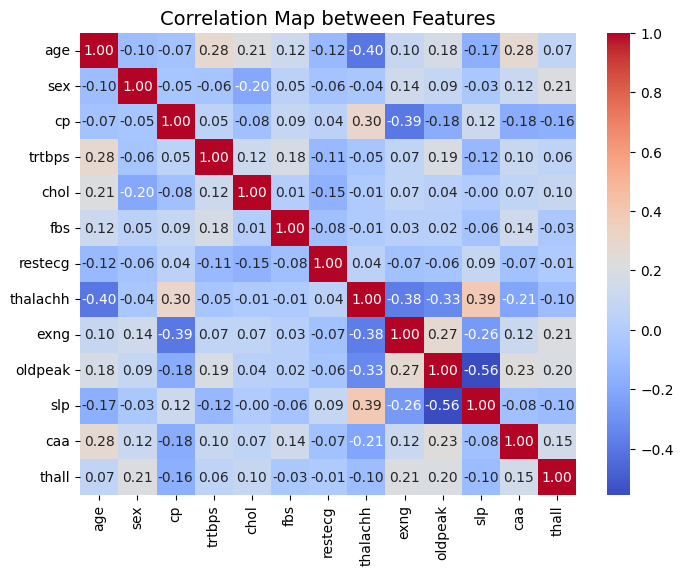

In [12]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Map between Features", fontsize=14)
plt.show()

## Preparing Data for Model

In [13]:
X = df[['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 'thalachh', 'exng', 'oldpeak', 'slp', 'caa', 'thall']]
Y = df['output']

## Normalize Data

In [14]:
scaler = preprocessing.StandardScaler().fit(X)
X = scaler.transform(X.astype(float))

## Splitting Data

In [15]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Select the Proper Algorithm 

## K nearest neighbor (KNN)

In [16]:
from sklearn.neighbors import KNeighborsClassifier

### Training

In [17]:
K = 6
neighbor = KNeighborsClassifier(n_neighbors = K).fit(X_train, Y_train)

### Predicting

In [18]:
Y_hat = neighbor.predict(X_test)

### Accuracy Evaluation

In [19]:
from sklearn import metrics

print("Train set Accuracy: ", metrics.accuracy_score(Y_train, neighbor.predict(X_train)))
print("Test set Accuracy: ", metrics.accuracy_score(Y_test, Y_hat))

Train set Accuracy:  0.859504132231405
Test set Accuracy:  0.9180327868852459


### Finding the Optimal K

In [20]:
Ks = 15
mean_accuracy = np.zeros((Ks-1))
std_accuracy = np.zeros((Ks-1))

for n in range(1 ,Ks):
    neighbor = KNeighborsClassifier(n_neighbors = n).fit(X_train, Y_train)
    Y_hat = neighbor.predict(X_test)
    mean_accuracy[n-1] = metrics.accuracy_score(Y_test, Y_hat)
    std_accuracy[n-1] = np.std(Y_hat == Y_test) / np.sqrt(Y_hat.shape[0])
mean_accuracy

array([0.83606557, 0.80327869, 0.86885246, 0.85245902, 0.90163934,
       0.91803279, 0.91803279, 0.86885246, 0.91803279, 0.8852459 ,
       0.90163934, 0.8852459 , 0.90163934, 0.86885246])

### Plotting

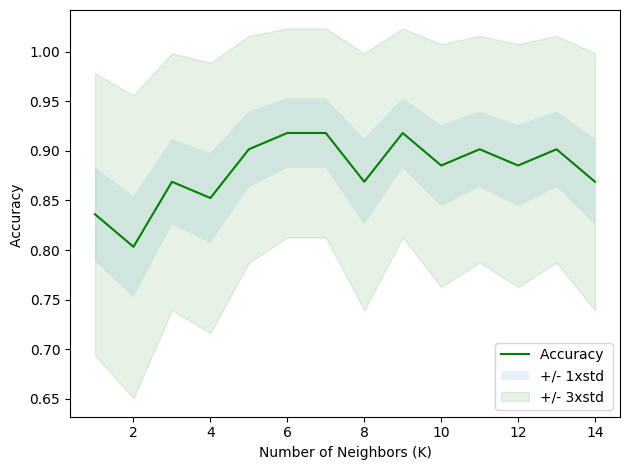

In [21]:
plt.plot(range(1,Ks),mean_accuracy,'g')
plt.fill_between(range(1,Ks),mean_accuracy - 1 * std_accuracy,mean_accuracy + 1 * std_accuracy, alpha=0.10)
plt.fill_between(range(1,Ks),mean_accuracy - 3 * std_accuracy,mean_accuracy + 3 * std_accuracy, alpha=0.10,color="green")
plt.legend(('Accuracy ', '+/- 1xstd','+/- 3xstd'))
plt.ylabel('Accuracy ')
plt.xlabel('Number of Neighbors (K)')
plt.tight_layout()
plt.show()

### Optimal K

In [22]:
print( "The best accuracy was with", mean_accuracy.max(), "with K =", mean_accuracy.argmax()+1) 

The best accuracy was with 0.9180327868852459 with K = 6


## Decision Tree

In [23]:
from sklearn.tree import DecisionTreeClassifier

### Training

In [24]:
decision_tree = DecisionTreeClassifier(criterion="entropy", max_depth = 4)
decision_tree.fit(X_train, Y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### Predicting

In [25]:
Y_hat = decision_tree.predict(X_test)

### Accuracy Evaluation

In [26]:
from sklearn import metrics

print("Train set Accuracy: ", metrics.accuracy_score(Y_train, decision_tree.predict(X_train)))
print("Test set Accuracy: ", metrics.accuracy_score(Y_test, Y_hat))

Train set Accuracy:  0.8553719008264463
Test set Accuracy:  0.8688524590163934


### Plotting

In [27]:
from  io import StringIO
import pydotplus
import matplotlib.image as mpimg
from sklearn import tree
import graphviz
%matplotlib inline 

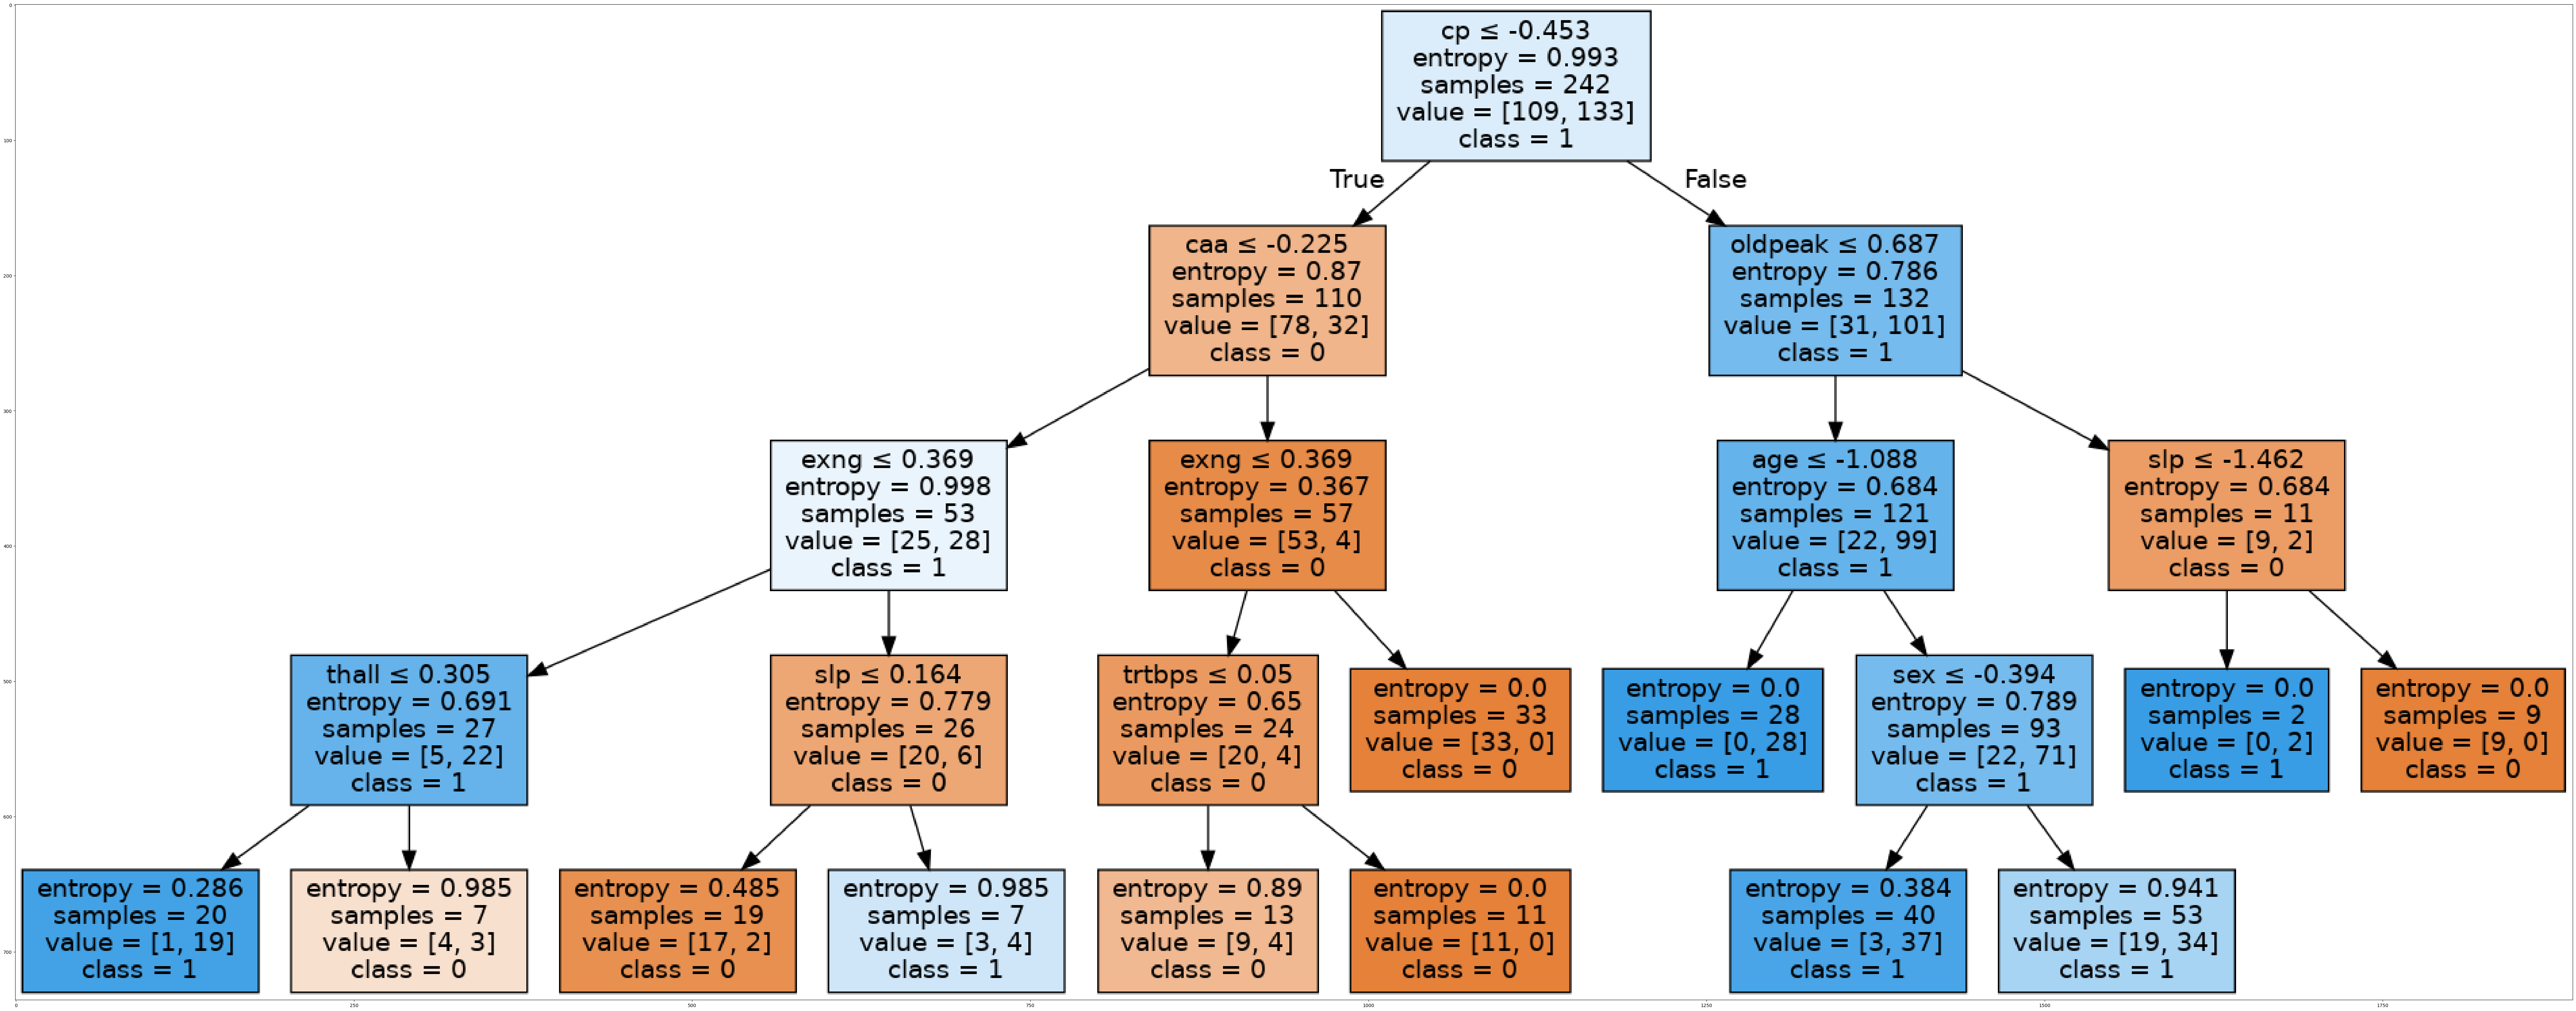

In [28]:
dot_data = StringIO()
filename = "decision_tree.png"
featureNames = df.columns[0:13]
out=tree.export_graphviz(
    decision_tree,
    feature_names = featureNames,
    out_file = dot_data,
    class_names = [str(c) for c in np.unique(Y_train)],
    filled = True,
    special_characters = True,
    rotate = False
)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())  
graph.write_png(filename)
img = mpimg.imread(filename)
plt.figure(figsize=(100, 200))
plt.imshow(img,interpolation='nearest')

## Logistic Regression

In [29]:
from sklearn.linear_model import LogisticRegression

### Training

In [30]:
logistic_regression = LogisticRegression(C=0.01, solver="liblinear")
logistic_regression.fit(X_train, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.01
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


### Predicting

In [31]:
Y_hat = logistic_regression.predict(X_test)
Y_hat_prob = logistic_regression.predict_proba(X_test)

### Evaluation

In [32]:
from sklearn.metrics import jaccard_score, log_loss, classification_report

print("Jaccard Score: ", jaccard_score(Y_test, Y_hat, pos_label=0))
print("---------------------------------------------------------------")
print("Log Loss: ", log_loss(Y_test, Y_hat_prob))
print("---------------------------------------------------------------")
print("Classification Report: ")
print(classification_report(Y_test, Y_hat))

Jaccard Score:  0.78125
---------------------------------------------------------------
Log Loss:  0.44627143384492585
---------------------------------------------------------------
Classification Report: 
              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



### Plotting

In [33]:
from sklearn.metrics import confusion_matrix
import itertools
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
print(confusion_matrix(Y_test, Y_hat, labels=[1,0]))

[[29  3]
 [ 4 25]]


Confusion matrix, without normalization
[[29  3]
 [ 4 25]]


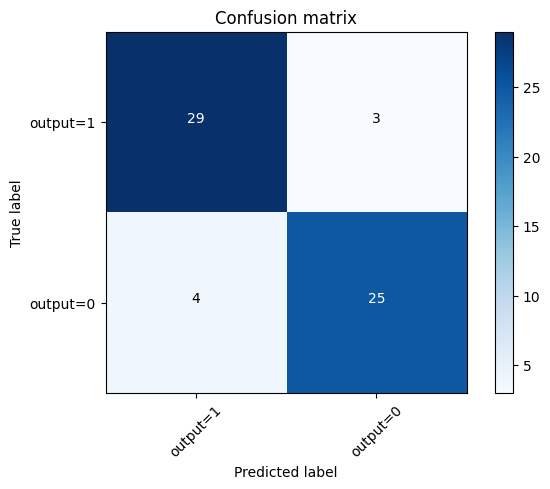

In [34]:
# Compute confusion matrix
cnf_matrix = confusion_matrix(Y_test, Y_hat, labels=[1,0])
np.set_printoptions(precision=2)


# Plot non-normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['output=1','output=0'],normalize= False,  title='Confusion matrix')

## Support Vector Machine (SVM)

In [35]:
from sklearn import svm

### Training

In [36]:
classifier = svm.SVC(kernel="rbf")
classifier.fit(X_train, Y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


### Predicting

In [37]:
Y_hat = classifier.predict(X_test)

### Evaluation

In [38]:
from sklearn.metrics import classification_report, confusion_matrix, jaccard_score
import itertools

print("Jaccard Score: ", jaccard_score(Y_test, Y_hat, pos_label=0))

Jaccard Score:  0.7647058823529411


### Plotting

In [39]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
print(confusion_matrix(Y_test, Y_hat, labels=[1,0]))

[[27  5]
 [ 3 26]]


              precision    recall  f1-score   support

           0       0.84      0.90      0.87        29
           1       0.90      0.84      0.87        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61

Confusion matrix, without normalization
[[27  5]
 [ 3 26]]


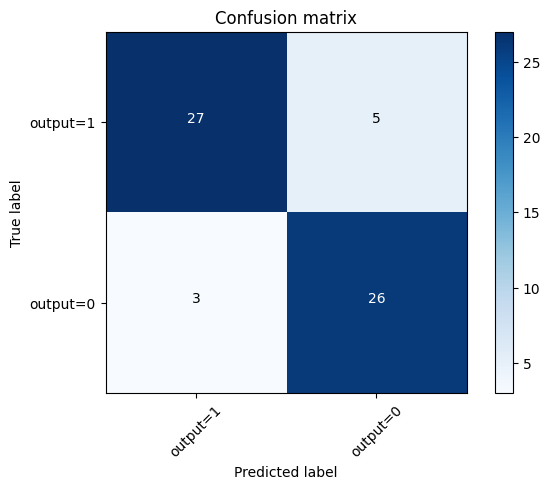

In [40]:
# Compute confusion matrix
cnf_matrix = confusion_matrix(Y_test, Y_hat, labels=[1,0])
np.set_printoptions(precision=2)

print(classification_report(Y_test, Y_hat))
# Plot non-normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['output=1','output=0'],normalize= False,  title='Confusion matrix')